# Exercise
Download employee retention dataset from here: https://www.kaggle.com/giripujar/hr-analytics.

1. Now do some exploratory data analysis to figure out which variables have direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)
2. Plot bar charts showing impact of employee salaries on retention
3. Plot bar charts showing corelation between department and employee retention
4. Now build logistic regression model using variables that were narrowed down in step 1
5. Measure the accuracy of the model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
df = pd.read_csv('HR_comma_sep.csv')
#df

In [3]:
#df.Department.unique()

In [4]:
%matplotlib inline
fig = plt.figure(figsize = (15, 5))
#plt.bar(df.Department,df.time_spend_company,color ='maroon',width = 0.4)
#plt.bar(df.Department,df.time_spend_company,color ='blue',width = 0.1)
#plt.grid()

<Figure size 1080x360 with 0 Axes>

In [5]:
#%matplotlib inline
fig = plt.figure(figsize = (6, 2))
#plt.bar(df.salary,df.time_spend_company,color ='maroon',width = 0.1)
#plt.grid()

<Figure size 432x144 with 0 Axes>

In [6]:
fig = plt.figure(figsize = (6, 2))
#plt.bar(df.salary,df.left,color ='maroon',width = 0.1)
#plt.grid()

<Figure size 432x144 with 0 Axes>

In [7]:
fig = plt.figure(figsize = (15, 5))
#plt.bar(df.promotion_last_5years,df.time_spend_company,color ='green',width = 0.1)
#plt.grid()

<Figure size 1080x360 with 0 Axes>

In [8]:
fig = plt.figure(figsize = (15, 5))
#plt.bar(df.satisfaction_level,df.time_spend_company,color ='red',width = 0.1)
#plt.grid()

<Figure size 1080x360 with 0 Axes>

In [9]:
df['left'].value_counts()

0    11428
1     3571
Name: left, dtype: int64

In [10]:
left = df[df.left==1]
left.shape

(3571, 10)

In [11]:
retained = df[df.left==0]
retained.shape

(11428, 10)

In [12]:
# used to group large amounts of data and compute operations on these groups.
df.groupby('left').mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


From above table we can draw following conclusions,

1. **Satisfaction Level**: Satisfaction level seems to be relatively low **(0.44)** in employees leaving the firm vs the retained ones __(0.66)__
2. **Average Monthly Hours**: Average monthly hours are higher in employees leaving the firm __(199 vs 207)__
3. **Promotion Last 5 Years**: Employees who are given promotion are likely to be retained at firm

#### Impact of salary on employee retention

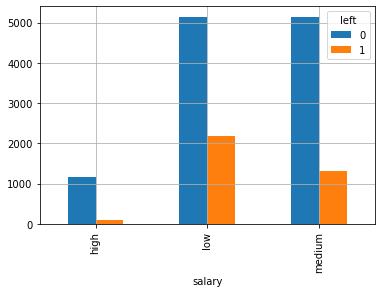

In [19]:
pd.crosstab(df.salary, df.left).plot(kind='bar')
# plt.grid()

Above bar chart shows employees with high salaries are likely to not leave the company

#### Department wise employee retention rate

<AxesSubplot:xlabel='Department'>

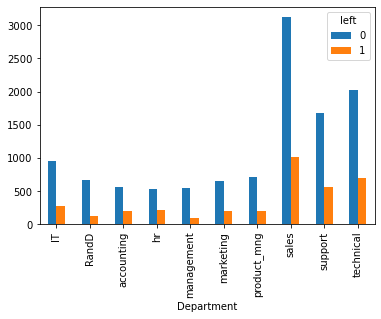

In [26]:
pd.crosstab(df.Department, df.left).plot(kind='bar')
# plt.grid()
# plt.figure(figsize=(20,7))

From above chart there seem to be some impact of department on employee retention but it is not major hence we will ignore department in our analysis

#### From the data analysis so far we can conclude that we will use following variables as independant variables in our model
1. **Satisfaction Level**
2. **Average Monthly Hours**
3. **Promotion Last 5 Years**
4. **Salary**

In [31]:
subdf = df[['satisfaction_level', 'average_montly_hours', 'promotion_last_5years', 'salary']]
subdf.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [14]:
df.drop_duplicates(subset=['Department'])

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
28,0.41,0.46,2,128,3,0,1,0,accounting,low
31,0.45,0.57,2,134,3,0,1,0,hr,low
35,0.10,0.94,6,255,4,0,1,0,technical,low
46,0.40,0.55,2,147,3,0,1,0,support,low
60,0.85,0.91,5,226,5,0,1,0,management,medium
61,0.11,0.93,7,308,4,0,1,0,IT,medium
66,0.43,0.54,2,153,3,0,1,0,product_mng,medium
77,0.40,0.54,2,137,3,0,1,0,marketing,medium
301,0.12,1.00,3,278,4,0,1,0,RandD,medium


In [15]:
df.left.unique()

array([1, 0], dtype=int64)

In [16]:
reg_model = linear_model.LinearRegression()
reg_model.fit(df[['satisfaction_level','last_evaluation','number_project','average_montly_hours','time_spend_company','Work_accident','promotion_last_5years'
]],df['left'])

LinearRegression()

In [17]:
reg_model.coef_

array([-6.59167242e-01,  9.89705187e-02, -3.46379974e-02,  6.45661737e-04,
        3.34831668e-02, -1.56896618e-01, -1.61137963e-01])